# Chapter 6 — Cleaning Text Without Over-Cleaning

Chapter 5 showed how to inspect a corpus and separate known fixture metadata from its main text.
This chapter treats cleaning as a set of modeling decisions about which information to preserve.

By the end of this chapter, you will be able to:

- explain why cleaning is not automatically beneficial;
- distinguish boundary cleanup from transformations inside the main text;
- compare whitespace, blank-line, case, and punctuation choices independently;
- identify which transformations lose information;
- measure how each choice changes length, line structure, and character vocabulary; and
- define a light cleaning policy for early character-level models.

## Cleaning Is a Modeling Choice

**Cleaning** changes text before tokenization or training.
The unchanged input is **raw text**, while the chosen result is **prepared text**.
A **cleaning policy** records the transformations used to create that result.

**Normalization** rewrites multiple forms into a chosen standard form.
For example, whitespace normalization can replace tabs and repeated spaces with single spaces.

A transformation is **destructive** when the original information cannot be recovered from its output alone.
Lowercasing is destructive because both `The` and `the` become `the`.

The goal is therefore not maximum cleaning.
The goal is a documented policy that removes known noise while preserving structure the model should learn.

## Start with an Inspectable Fixture

The fixture extends Chapter 5's example with boundary whitespace, repeated spaces, and a tab.
It also retains capitalization, punctuation, paragraph breaks, metadata, and an end marker.
The ordinary and `repr` views reveal different parts of that structure.

In [1]:
raw_corpus_text = (
    "\n\n"
    "TITLE: Tiny Public-Domain-Style Corpus\n"
    "SOURCE: Local notebook fixture\n"
    "\n"
    "The   dog ran across the yard.\n"
    "The cat\tsat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back.\n"
    "\n"
    "END OF FIXTURE"
    "\n\n"
)

print("Raw text:")
print(raw_corpus_text)
print("Technical representation:")
print(repr(raw_corpus_text))

Raw text:


TITLE: Tiny Public-Domain-Style Corpus
SOURCE: Local notebook fixture

The   dog ran across the yard.
The cat	sat near the window.

The dog looked at the cat!
The cat looked back.

END OF FIXTURE


Technical representation:
'\n\nTITLE: Tiny Public-Domain-Style Corpus\nSOURCE: Local notebook fixture\n\nThe   dog ran across the yard.\nThe cat\tsat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.\n\nEND OF FIXTURE\n\n'


## Establish the Main-Text Baseline

The first step reuses Chapter 5's fixture-specific extraction rule.
It strips whitespace around the entire corpus and removes the known metadata and footer.
It does not alter spacing, blank lines, case, or punctuation inside the main text.

This extracted text becomes the shared baseline for later experiments.
Comparing each transformation with the same baseline prevents one choice from hiding another choice's effect.

In [2]:
def extract_main_text_from_fixture(corpus_text: str) -> str:
    lines = corpus_text.strip().splitlines()

    if "" not in lines:
        raise ValueError("Expected a blank line after the metadata.")
    if not lines or lines[-1] != "END OF FIXTURE":
        raise ValueError("Expected the fixture's end marker.")

    first_blank_line_index = lines.index("")
    main_text_lines = lines[first_blank_line_index + 1 : -1]
    return "\n".join(main_text_lines).strip()


main_text = extract_main_text_from_fixture(raw_corpus_text)

print("Main-text baseline:")
print(main_text)
print("Technical representation:")
print(repr(main_text))

Main-text baseline:
The   dog ran across the yard.
The cat	sat near the window.

The dog looked at the cat!
The cat looked back.
Technical representation:
'The   dog ran across the yard.\nThe cat\tsat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Measure Every Version the Same Way

A useful comparison needs consistent measurements.
The helper reports character count, line count, blank-line count, and character-vocabulary size.
These measurements describe the text but do not decide whether a transformation is appropriate.

In [3]:
def measure_text(text: str) -> dict[str, int]:
    lines = text.splitlines()
    blank_line_count = sum(not line.strip() for line in lines)

    return {
        "characters": len(text),
        "lines": len(lines),
        "blank_lines": blank_line_count,
        "unique_characters": len(set(text)),
    }


main_text_measurements = measure_text(main_text)
for measurement_name, value in main_text_measurements.items():
    print(f"{measurement_name:>18}: {value}")

        characters: 108
             lines: 5
       blank_lines: 1
 unique_characters: 23


## Normalize Horizontal Whitespace

The baseline contains three spaces between `The` and `dog` and a tab between `cat` and `sat`.
The function below collapses whitespace inside each non-empty line to single spaces.
It preserves line boundaries and blank lines.

This transformation is destructive because the original spacing and tabs cannot be reconstructed afterward.
It is reasonable here only because those differences represent deliberate fixture noise rather than structure we want the model to learn.

In [4]:
def normalize_whitespace_inside_lines(text: str) -> str:
    normalized_lines = []

    for line in text.splitlines():
        if line.strip():
            normalized_lines.append(" ".join(line.split()))
        else:
            normalized_lines.append("")

    return "\n".join(normalized_lines)


normalized_whitespace_text = normalize_whitespace_inside_lines(main_text)

print(normalized_whitespace_text)
print()
print("Technical representation:")
print(repr(normalized_whitespace_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

Technical representation:
'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Decide Whether Blank Lines Matter

A blank line separates the fixture's two paragraphs.
Removing blank lines shortens the sequence and removes the distinction between paragraph and ordinary line boundaries.

The next transformation removes only empty lines.
It keeps one newline between every remaining pair of lines.

In [5]:
def remove_blank_lines(text: str) -> str:
    non_empty_lines = [line for line in text.splitlines() if line.strip()]
    return "\n".join(non_empty_lines)


no_blank_lines_text = remove_blank_lines(main_text)

print("Blank lines in baseline:", measure_text(main_text)["blank_lines"])
print("Blank lines after removal:", measure_text(no_blank_lines_text)["blank_lines"])
print("Resulting text:")
print(no_blank_lines_text)

Blank lines in baseline: 1
Blank lines after removal: 0
Resulting text:
The   dog ran across the yard.
The cat	sat near the window.
The dog looked at the cat!
The cat looked back.


## Decide Whether Case Matters

Lowercasing merges uppercase and lowercase forms into lowercase forms.
This can reduce a small vocabulary, but it prevents the model from learning capitalization.

Comparing character sets shows exactly which symbols disappear or appear.
The transformation keeps the sequence length unchanged for this English fixture.

In [6]:
lowercase_text = main_text.lower()
characters_removed_by_lowercasing = sorted(set(main_text) - set(lowercase_text))
characters_added_by_lowercasing = sorted(set(lowercase_text) - set(main_text))

print(
    "Characters removed:",
    [repr(character) for character in characters_removed_by_lowercasing],
)
print(
    "Characters added:",
    [repr(character) for character in characters_added_by_lowercasing],
)
print("Length unchanged:", len(lowercase_text) == len(main_text))
print("Unique characters before:", len(set(main_text)))
print("Unique characters after:", len(set(lowercase_text)))

Characters removed: ["'T'"]
Characters added: []
Length unchanged: True
Unique characters before: 23
Unique characters after: 22


## Decide Whether Punctuation Matters

Punctuation marks sentence boundaries, emphasis, quotations, and relationships inside words.
Deleting it reduces the vocabulary but prevents a model from learning to generate it.

The function below removes characters in Python's ASCII punctuation set.
That scope is sufficient for this fixture but is not a complete Unicode punctuation policy.

Replacing punctuation with spaces can avoid joining neighboring text, although it still loses the punctuation itself.

In [7]:
from string import punctuation


def remove_ascii_punctuation(text: str) -> str:
    return "".join(character for character in text if character not in punctuation)


def replace_ascii_punctuation_with_spaces(text: str) -> str:
    return "".join(" " if character in punctuation else character for character in text)


no_punctuation_text = remove_ascii_punctuation(main_text)
joined_word_example = remove_ascii_punctuation("high-quality")
separated_word_example = replace_ascii_punctuation_with_spaces("high-quality")

print("Punctuation-free fixture:")
print(no_punctuation_text)
print("Deletion example:", joined_word_example)
print("Replacement example:", separated_word_example)

Punctuation-free fixture:
The   dog ran across the yard
The cat	sat near the window

The dog looked at the cat
The cat looked back
Deletion example: highquality
Replacement example: high quality


## Compare Independent Choices

Each version in the next table applies one transformation directly to the main-text baseline.
This design isolates the effect of each choice.
A smaller value is a change in the modeling problem rather than automatic evidence of improvement.

In [8]:
independent_versions = [
    ("main-text baseline", main_text),
    ("normalized whitespace", normalized_whitespace_text),
    ("no blank lines", no_blank_lines_text),
    ("lowercase", lowercase_text),
    ("no ASCII punctuation", no_punctuation_text),
]

print(
    f"{'Version':<24} {'Characters':>10} {'Lines':>8} {'Blank':>8} {'Vocabulary':>12}"
)
print("-" * 66)
for version_name, text in independent_versions:
    measurements = measure_text(text)
    print(
        f"{version_name:<24} "
        f"{measurements['characters']:>10} "
        f"{measurements['lines']:>8} "
        f"{measurements['blank_lines']:>8} "
        f"{measurements['unique_characters']:>12}"
    )

Version                  Characters    Lines    Blank   Vocabulary
------------------------------------------------------------------
main-text baseline              108        5        1           23
normalized whitespace           106        5        1           22
no blank lines                  107        4        0           23
lowercase                       108        5        1           22
no ASCII punctuation            104        5        1           21


## Compare Cumulative Policies

A real preparation policy usually combines several choices.
The **light policy** normalizes accidental horizontal whitespace while preserving blank lines, capitalization, and punctuation.
The **aggressive policy** also removes blank lines and punctuation before lowercasing.

The aggressive version is useful as a contrast rather than a recommendation.

In [9]:
lightly_prepared_text = normalized_whitespace_text
aggressively_prepared_text = remove_blank_lines(lightly_prepared_text)
aggressively_prepared_text = remove_ascii_punctuation(aggressively_prepared_text)
aggressively_prepared_text = aggressively_prepared_text.lower()

policy_versions = [
    ("main-text baseline", main_text),
    ("light policy", lightly_prepared_text),
    ("aggressive policy", aggressively_prepared_text),
]

for policy_name, text in policy_versions:
    print(f"{policy_name}:")
    print(repr(text))
    print(measure_text(text))
    print()

main-text baseline:
'The   dog ran across the yard.\nThe cat\tsat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'
{'characters': 108, 'lines': 5, 'blank_lines': 1, 'unique_characters': 23}

light policy:
'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'
{'characters': 106, 'lines': 5, 'blank_lines': 1, 'unique_characters': 22}

aggressive policy:
'the dog ran across the yard\nthe cat sat near the window\nthe dog looked at the cat\nthe cat looked back'
{'characters': 101, 'lines': 4, 'blank_lines': 0, 'unique_characters': 19}



The plot compares character-vocabulary size across the cumulative policies.
Its purpose is to make the aggressive policy's simplification visible without treating a smaller vocabulary as inherently better.

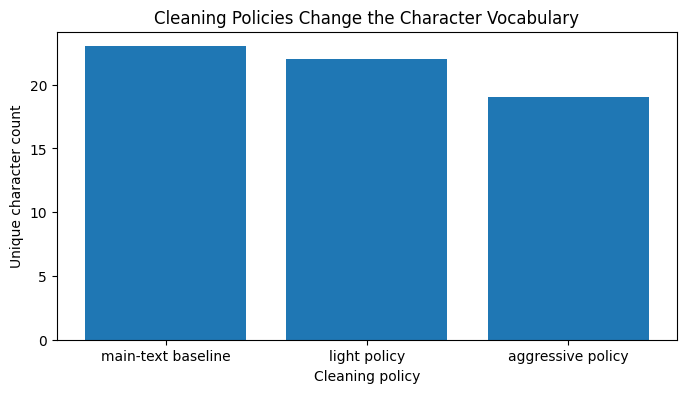

In [10]:
import matplotlib.pyplot as plt

policy_names = [policy_name for policy_name, text in policy_versions]
vocabulary_sizes = [len(set(text)) for policy_name, text in policy_versions]

plt.figure(figsize=(8, 4))
plt.bar(policy_names, vocabulary_sizes)
plt.xlabel("Cleaning policy")
plt.ylabel("Unique character count")
plt.title("Cleaning Policies Change the Character Vocabulary")
plt.show()

## Choose the Light Policy

The early character-level model should learn ordinary capitalization, punctuation, and paragraph structure.
The light policy therefore removes fixture metadata and known spacing noise while retaining those features.

The final checks express that policy as testable conditions.
They also confirm that the original raw fixture remains unchanged for future comparison.

In [11]:
prepared_text_for_character_modeling = lightly_prepared_text

assert raw_corpus_text.startswith("\n\n")
assert "TITLE:" not in prepared_text_for_character_modeling
assert "END OF FIXTURE" not in prepared_text_for_character_modeling
assert "\t" not in prepared_text_for_character_modeling
assert "   " not in prepared_text_for_character_modeling
assert "\n\n" in prepared_text_for_character_modeling
assert "The" in prepared_text_for_character_modeling
assert "." in prepared_text_for_character_modeling
assert "!" in prepared_text_for_character_modeling

print("Prepared text for character modeling:")
print(prepared_text_for_character_modeling)
print()
print("All light-cleaning policy checks passed.")

Prepared text for character modeling:
The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

All light-cleaning policy checks passed.


## Key Takeaways

- Cleaning defines what information a model can learn from its corpus.
- Boundary cleanup and corpus-specific extraction should precede experiments on the main text.
- Independent comparisons isolate one transformation at a time.
- Cumulative policies show the actual data that a later model would receive.
- Whitespace normalization, blank-line removal, lowercasing, and punctuation removal all lose information.
- Measurements reveal what changed but cannot choose the correct policy by themselves.
- The selected light policy removes known noise while preserving punctuation, capitalization, and paragraph structure.

## Next Chapter

Chapter 7 turns the lightly prepared text into a character-level tokenizer.
It will define a vocabulary and exact encoding and decoding operations so the preserved text structure can become model-ready token IDs.